In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv('TSLA.CSV')
data

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2019-05-21,39.551998,41.480000,39.208000,41.015999,90019500,0,0.0
1,2019-05-22,39.820000,40.787998,38.355999,38.546001,93426000,0,0.0
2,2019-05-23,38.868000,39.894001,37.243999,39.098000,132735500,0,0.0
3,2019-05-24,39.966000,39.995998,37.750000,38.125999,70683000,0,0.0
4,2019-05-28,38.240002,39.000000,37.570000,37.740002,51564500,0,0.0
...,...,...,...,...,...,...,...,...
753,2022-05-16,767.159973,769.760010,719.090027,724.369995,28699500,0,0.0
754,2022-05-17,747.359985,764.479980,728.849976,761.609985,26745400,0,0.0
755,2022-05-18,744.520020,760.500000,700.809998,709.809998,29270600,0,0.0
756,2022-05-19,707.000000,734.000000,694.109985,709.419983,30098900,0,0.0


In [3]:
data.head().T

,0,1,2,3,4
Date,2019-05-21,2019-05-22,2019-05-23,2019-05-24,2019-05-28
Open,39.551998,39.82,38.868,39.966,38.240002
High,41.48,40.787998,39.894001,39.995998,39.0
Low,39.208,38.355999,37.243999,37.75,37.57
Close,41.015999,38.546001,39.098,38.125999,37.740002
Volume,90019500,93426000,132735500,70683000,51564500
Dividends,0,0,0,0,0
Stock Splits,0.0,0.0,0.0,0.0,0.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 758 entries, 0 to 757
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          758 non-null    object 
 1   Open          758 non-null    float64
 2   High          758 non-null    float64
 3   Low           758 non-null    float64
 4   Close         758 non-null    float64
 5   Volume        758 non-null    int64  
 6   Dividends     758 non-null    int64  
 7   Stock Splits  758 non-null    float64
dtypes: float64(5), int64(2), object(1)
memory usage: 47.5+ KB


In [5]:
stock_data=data[['Date','Close']]
stock_data

,Date,Close
0,2019-05-21,41.015999
1,2019-05-22,38.546001
2,2019-05-23,39.098000
3,2019-05-24,38.125999
4,2019-05-28,37.740002
...,...,...
753,2022-05-16,724.369995
754,2022-05-17,761.609985
755,2022-05-18,709.809998
756,2022-05-19,709.419983


In [6]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 758 entries, 0 to 757
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    758 non-null    object 
 1   Close   758 non-null    float64
dtypes: float64(1), object(1)
memory usage: 12.0+ KB


In [7]:
stock_data['Date']=pd.to_datetime(stock_data['Date'])
stock_data['Date']

0     2019-05-21
1     2019-05-22
2     2019-05-23
3     2019-05-24
4     2019-05-28
         ...    
753   2022-05-16
754   2022-05-17
755   2022-05-18
756   2022-05-19
757   2022-05-20
Name: Date, Length: 758, dtype: datetime64[ns]

In [8]:
# Time series and traditional data >> the difference is time series has a timecomponent
# Therefore data column should be index
# slicing of ddata on date column becomes easy
# Visyualization is simple 
# Libraries related to forecasting models assumes that there is a  data/time column.

In [9]:
stock_data=stock_data.set_index('Date')
stock_data

,Close
Date,
2019-05-21,41.015999
2019-05-22,38.546001
2019-05-23,39.098000
2019-05-24,38.125999
2019-05-28,37.740002
...,...
2022-05-16,724.369995
2022-05-17,761.609985
2022-05-18,709.809998


In [10]:
stock_data.describe()

,Close
count,758.000000
mean,485.531513
std,353.160353
min,35.793999
25%,112.323500
50%,488.125000
75%,762.142502
max,1229.910034


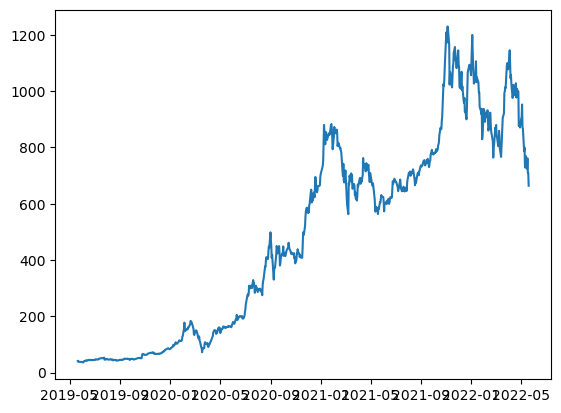

In [11]:
plt.plot(stock_data.Close)

(array([228.,  57.,  38.,  59.,  50., 127.,  81.,  44.,  59.,  15.]),
 array([  35.79399872,  155.20560226,  274.61720581,  394.02880936,
         513.4404129 ,  632.85201645,  752.26362   ,  871.67522354,
         991.08682709, 1110.49843063, 1229.91003418]),
 <BarContainer object of 10 artists>)

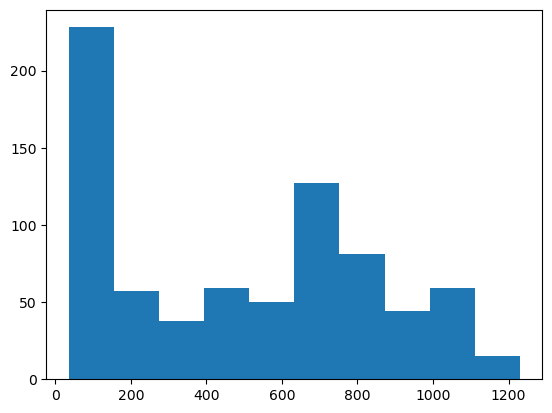

In [12]:
plt.hist(stock_data.Close)

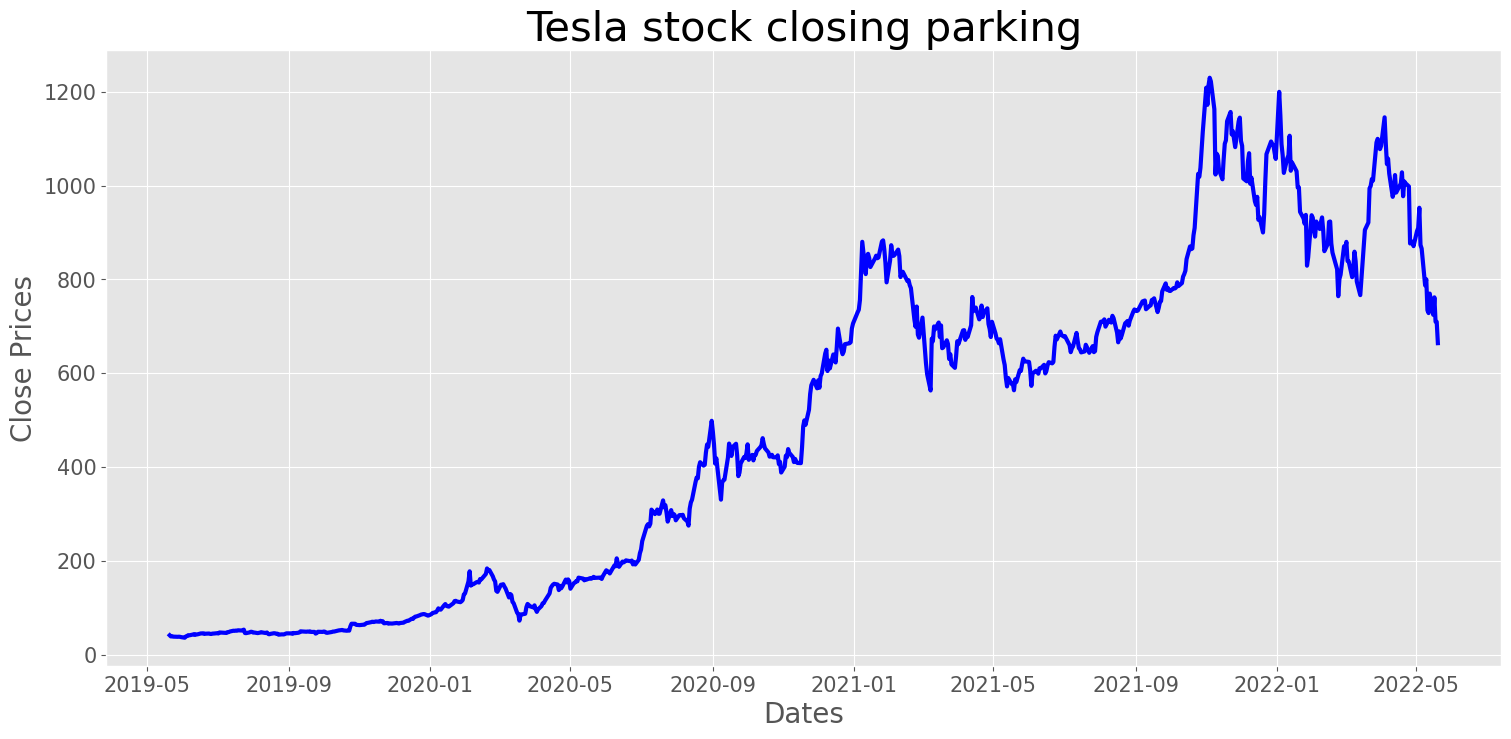

In [13]:
# Line chart for closing price
plt.style.use('ggplot')
plt.figure(figsize=(18,8))
plt.grid(True)
plt.xlabel('Dates', fontsize=20)
plt.xticks(fontsize=15)
plt.ylabel('Close Prices', fontsize=20)
plt.yticks(fontsize=15)
plt.plot(stock_data['Close'], linewidth=3, color='blue')
plt.title("Tesla stock closing parking", fontsize=30)
plt.show()

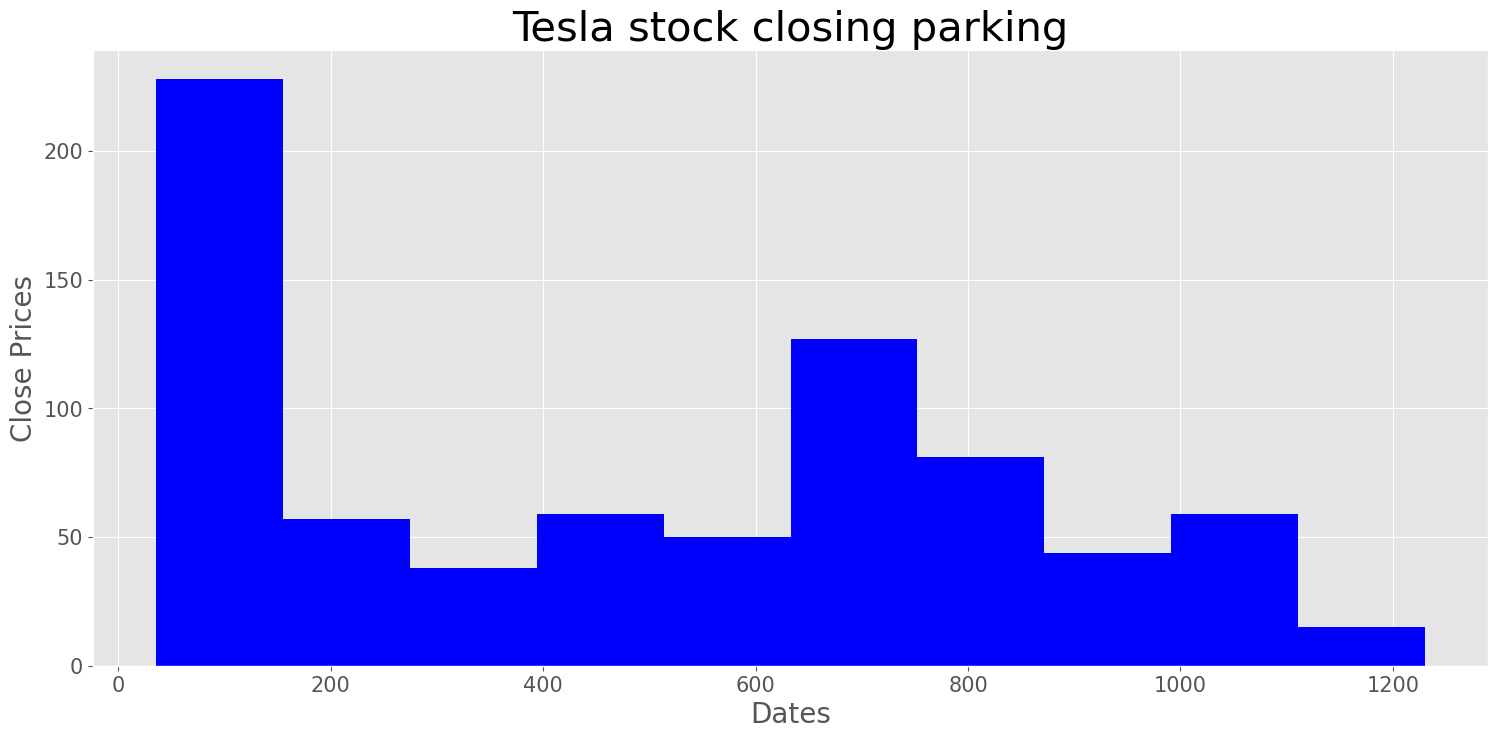

In [14]:
#Histogram
plt.style.use('ggplot')
plt.figure(figsize=(18,8))
plt.grid(True)
plt.xlabel('Dates', fontsize=20)
plt.xticks(fontsize=15)
plt.ylabel('Close Prices', fontsize=20)
plt.yticks(fontsize=15)
plt.hist(stock_data['Close'], linewidth=3, color='blue')
plt.title("Tesla stock closing parking", fontsize=30)
plt.show()

<Axes: ylabel='Density'>

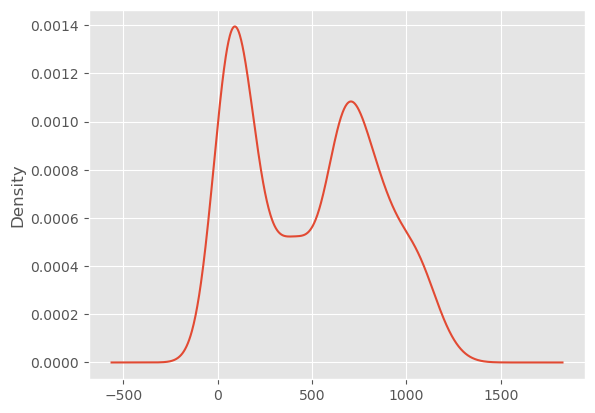

In [15]:
# distribution plot of closing price
df_close=stock_data.Close
df_close.plot(kind='kde')

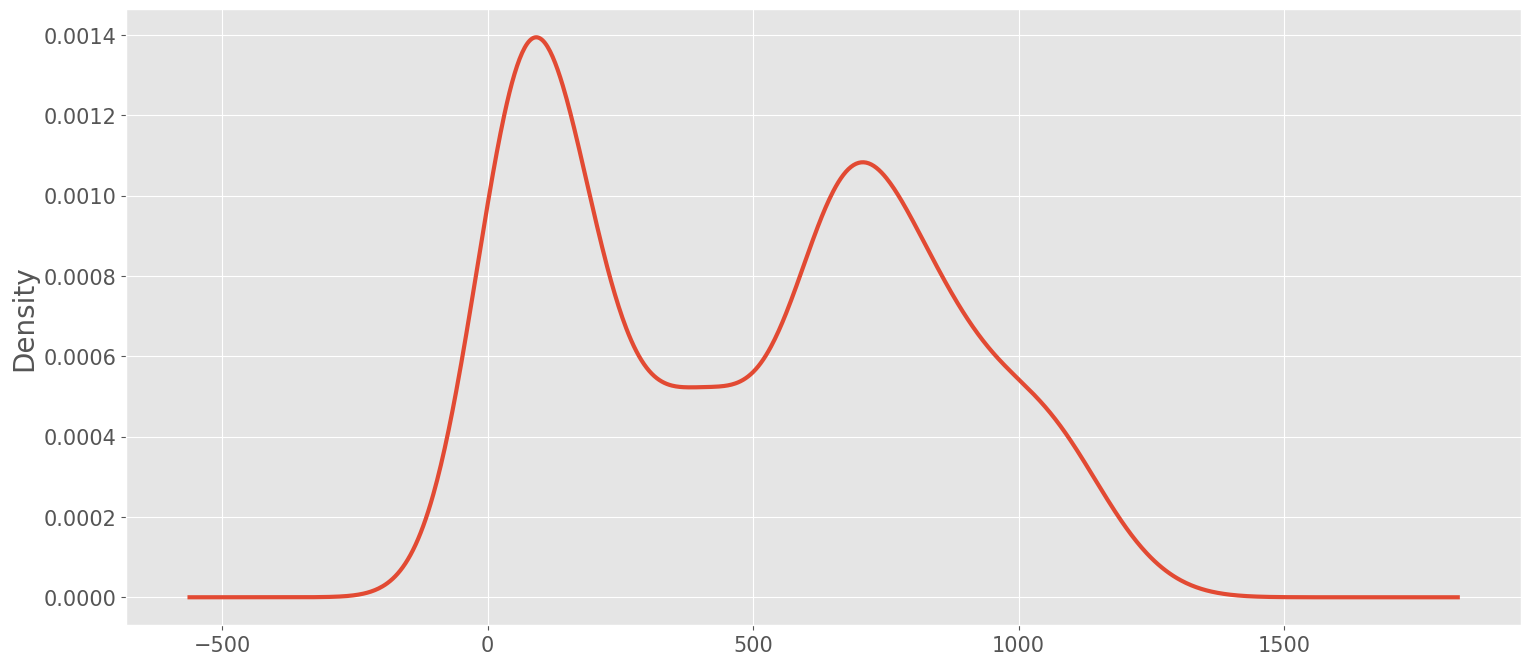

In [16]:
df_close=stock_data.Close
df_close.plot(kind='kde',figsize=(18,8), linewidth=3)
plt.xticks(fontsize=15)
plt.grid('both')
plt.ylabel('Density', fontsize=20)
plt.yticks(fontsize=15)
plt.show()

In [17]:
rolling_mean=stock_data['Close'].rolling(48).mean()
rolling_std=stock_data['Close'].rolling(48).std()

In [18]:
rolling_mean

Date
2019-05-21           NaN
2019-05-22           NaN
2019-05-23           NaN
2019-05-24           NaN
2019-05-28           NaN
                 ...    
2022-05-16    936.968953
2022-05-17    934.940620
2022-05-18    932.263746
2022-05-19    930.473537
2022-05-20    928.338746
Name: Close, Length: 758, dtype: float64

In [19]:
rolling_std

Date
2019-05-21           NaN
2019-05-22           NaN
2019-05-23           NaN
2019-05-24           NaN
2019-05-28           NaN
                 ...    
2022-05-16    113.126351
2022-05-17    115.404496
2022-05-18    119.124084
2022-05-19    121.840134
2022-05-20    125.615809
Name: Close, Length: 758, dtype: float64

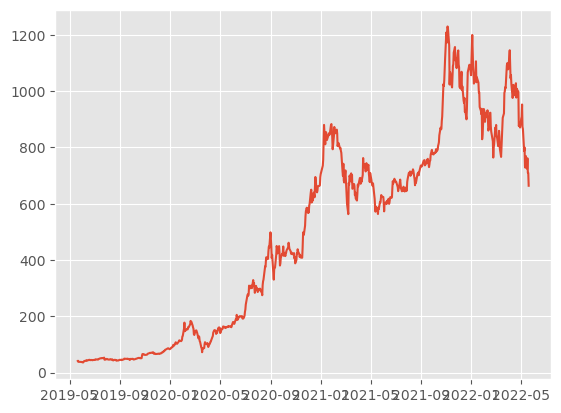

In [20]:
plt.plot(stock_data.Close)

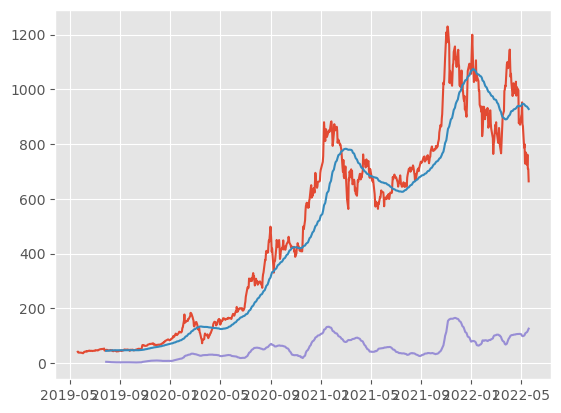

In [21]:
plt.plot(stock_data.Close)
plt.plot(rolling_mean)
plt.plot(rolling_std)

In [22]:
# From the above plot, it is clear that time series is non stationary.
# Lets verify by stastical test >> ADF Test

In [23]:
# ADF test >> In ADF test, the null hypothesis is the time series is stationary, and if pvalue  < 0.05, reject type null hypothesis

In [24]:
from statsmodels.tsa.stattools import adfuller
adft=adfuller(stock_data['Close'])
adft

(np.float64(-1.363008581703748),
 np.float64(0.5998762543050701),
 9,
 748,
 {'1%': np.float64(-3.43912257105195),
  '5%': np.float64(-2.8654117005229844),
  '10%': np.float64(-2.568831705010152)},
 np.float64(6794.359259220987))

In [25]:
pd.Series(adft[0:4], index=['test_statistics', 'p_values', 'lag', 'no. of data points'])

test_statistics        -1.363009
p_values                0.599876
lag                     9.000000
no. of data points    748.000000
dtype: float64

In [26]:
# Here pvalue > 0.05, it means  reject null hypothesis >> series is non stationaty

In [27]:
# test for stationarity 

In [28]:
def test_stationarity(timeseries):
    # determing rolling statistics
    rolmean=timeseries.rolling(48).mean() # rolling mean
    rolstd=timeseries.rolling(48).std()  # rolling standard deviation
    # plot rolling statistics:
    plt.figure(figsize=(18, 8))
    plt.grid('both')
    plt.plot(timeseries, color='blue', label='Original', linewidth=3)
    plt.plot(rolmean, color='red', label='Rolling_mean', linewidth=3)
    plt.plot(rolstd, color='black', label='Rolling Std', linewidth=4)
    plt.legend(loc='best',fontsize=20, shadow=True, facecolor='lightpink',edgecolor='k')
    plt.title('Rolling Mean and Standard Deviation ', fontsize=25)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.show(block='False')

    print("Result of dickey fuller test")
    adft=adfuller(timeseries, autolag='AIC')
    # output for dt will give us without defining that values are.
    # hence we manually write whatvalue does it explains using a for loop
    output=pd.Series(adft[0:4], index=['Test Stastics','p-value','No. of lags used','Number of observation used'])
    for key, values in adft[4].items():
        output['critical value (%s) %key'] = values
    print(output)    

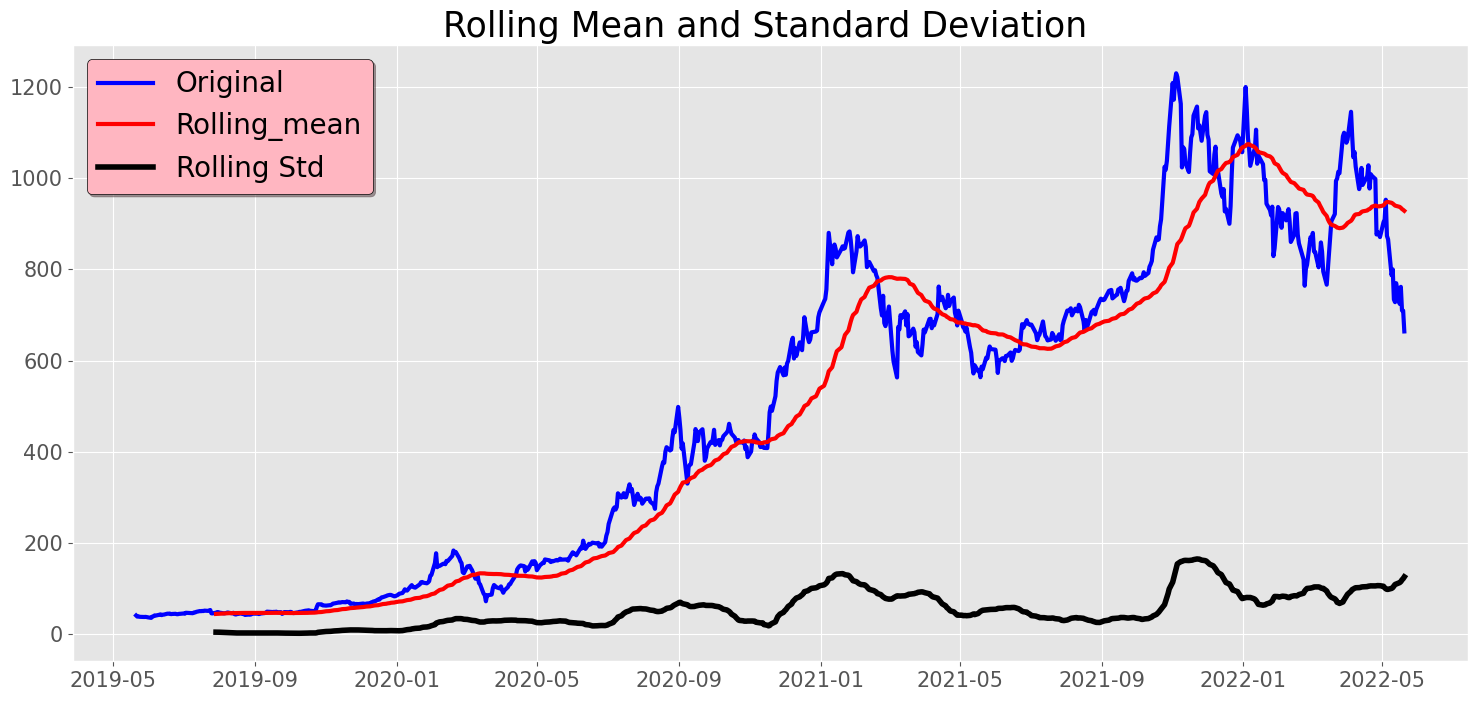

Result of dickey fuller test
Test Stastics                  -1.363009
p-value                         0.599876
No. of lags used                9.000000
Number of observation used    748.000000
critical value (%s) %key       -2.568832
dtype: float64


In [29]:
test_stationarity(stock_data.Close)

In [30]:
# Series is not stationary 

# A time series is made of level, trend, seasonality, noise
# A time series is of two types

In [31]:
from statsmodels.tsa.seasonal import seasonal_decompose
result=seasonal_decompose(stock_data[['Close']], period=12) # for 12 month

In [32]:
result.seasonal

Date
2019-05-21   -2.346452
2019-05-22    3.768884
2019-05-23   -0.777006
2019-05-24   -0.654226
2019-05-28   -2.737845
                ...   
2022-05-16    2.149519
2022-05-17    1.323680
2022-05-18    1.837638
2022-05-19   -2.346452
2022-05-20    3.768884
Name: seasonal, Length: 758, dtype: float64

<Figure size 2000x1000 with 0 Axes>

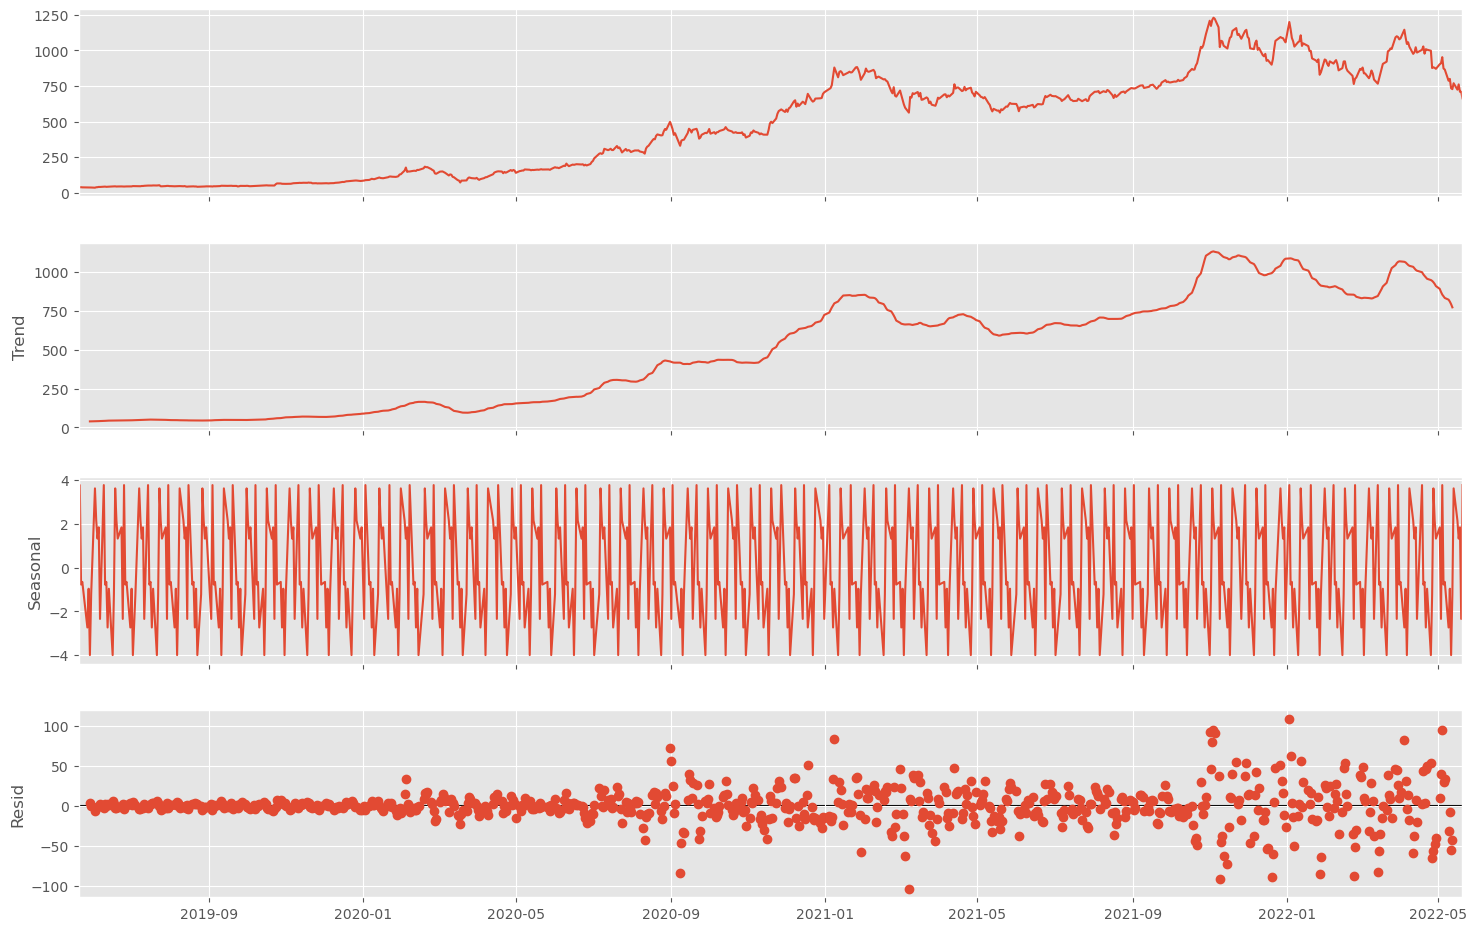

In [33]:
fig=plt.figure(figsize=(20,10))
fig=result.plot()
fig.set_size_inches(17,10)

<Figure size 2000x1000 with 0 Axes>

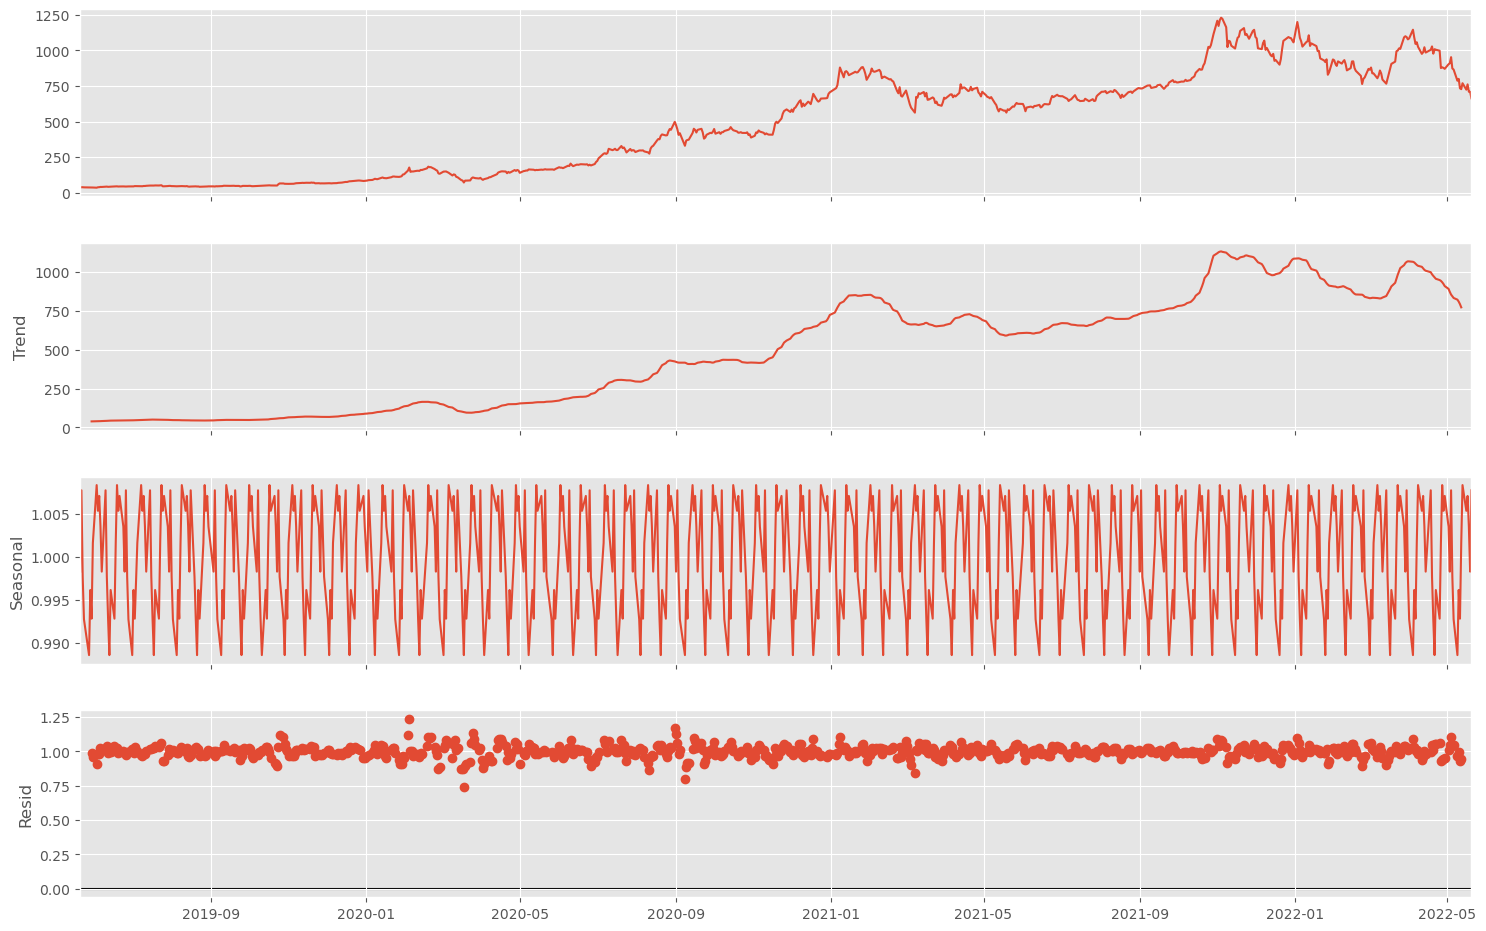

In [34]:
from statsmodels.tsa.seasonal import seasonal_decompose
result=seasonal_decompose(stock_data[['Close']], period=12, model='multiplicative')
fig=plt.figure(figsize=(20,10))
fig=result.plot()
fig.set_size_inches(17,10)

<Axes: ylabel='Close'>

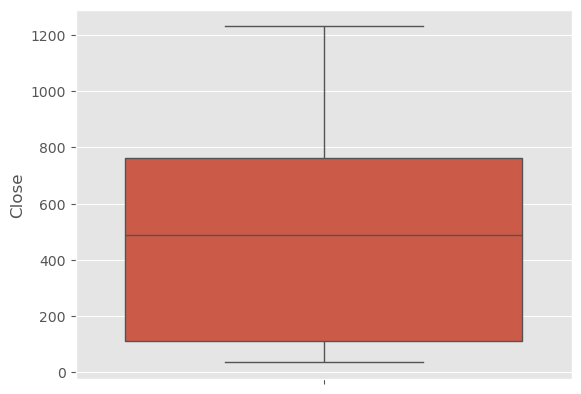

In [35]:
sns.boxplot(stock_data.Close)

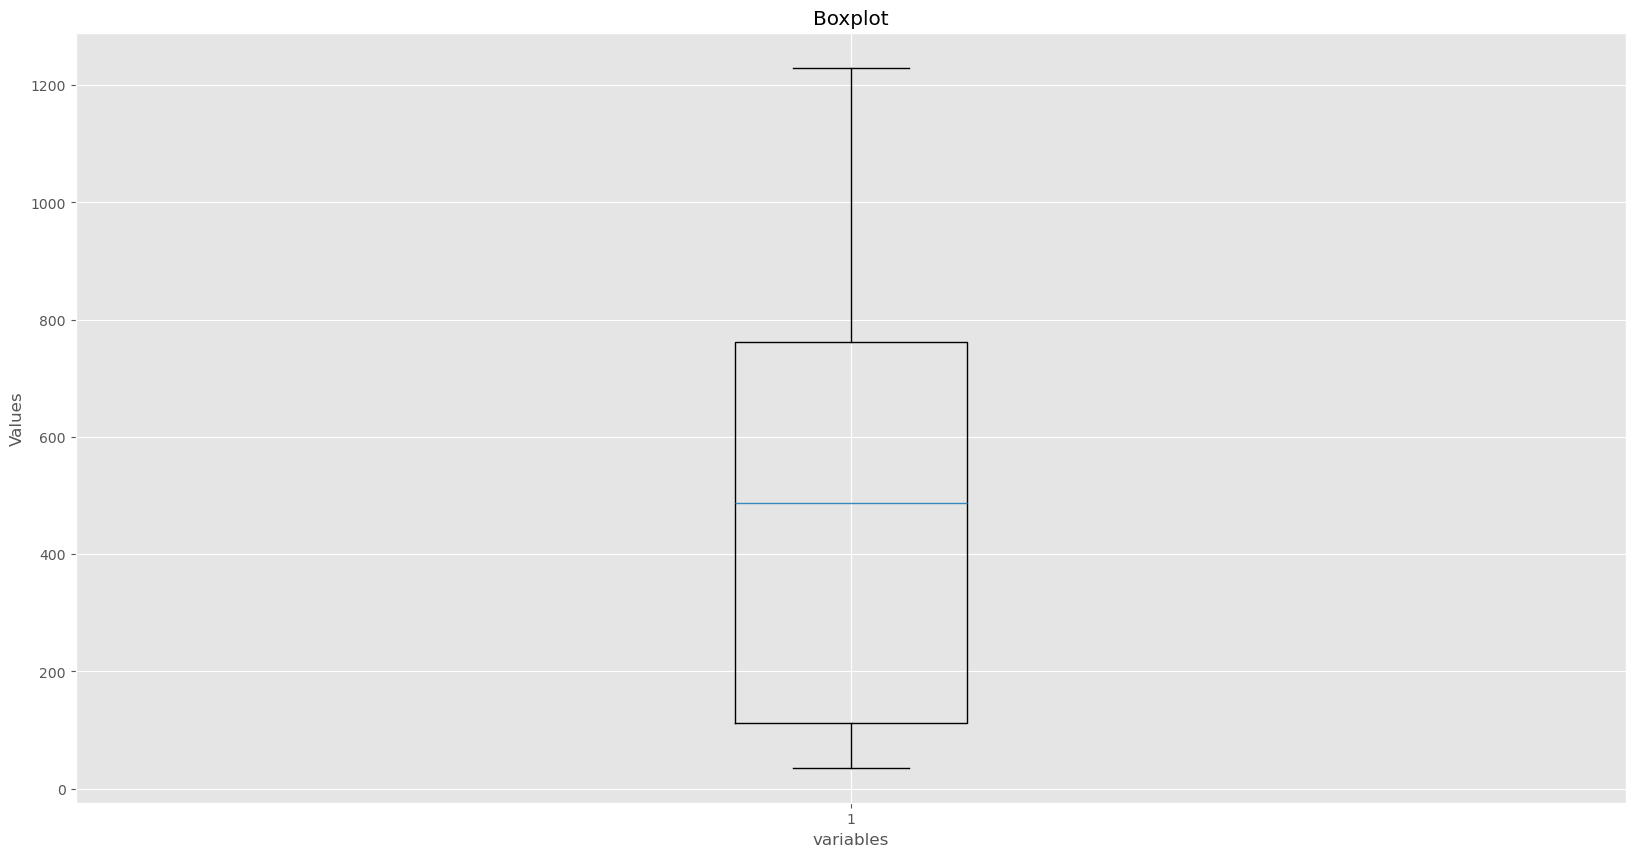

In [36]:
pfg, ax=plt.subplots(figsize=(20,10))
ax.boxplot(stock_data['Close'])
ax.set_xlabel('variables')
ax.set_ylabel('Values')
ax.set_title('Boxplot')
plt.show()

In [37]:
# No outliers

In [38]:
# ACF and PACF Plot

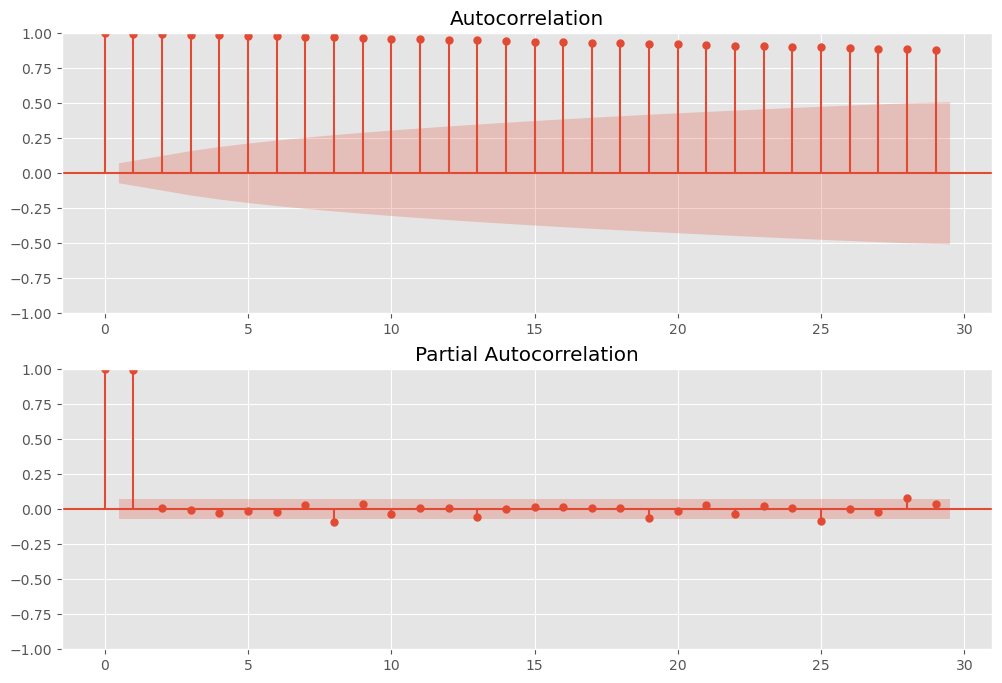

In [39]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes=plt.subplots(2,1,figsize=(12,8))
plot_acf(stock_data, ax=axes[0])
plot_pacf(stock_data, ax=axes[1])
plt.show()
# since series is not stationary, results are not good

In [40]:
# To make time series stationary >> differencing
df_close=df_close.diff()
df_close=df_close.dropna()

In [41]:
df_close

Date
2019-05-22    -2.469997
2019-05-23     0.551998
2019-05-24    -0.972000
2019-05-28    -0.385998
2019-05-29     0.231998
                ...    
2022-05-16   -45.220032
2022-05-17    37.239990
2022-05-18   -51.799988
2022-05-19    -0.390015
2022-05-20   -45.519958
Name: Close, Length: 757, dtype: float64

In [42]:
# Now check again stationary

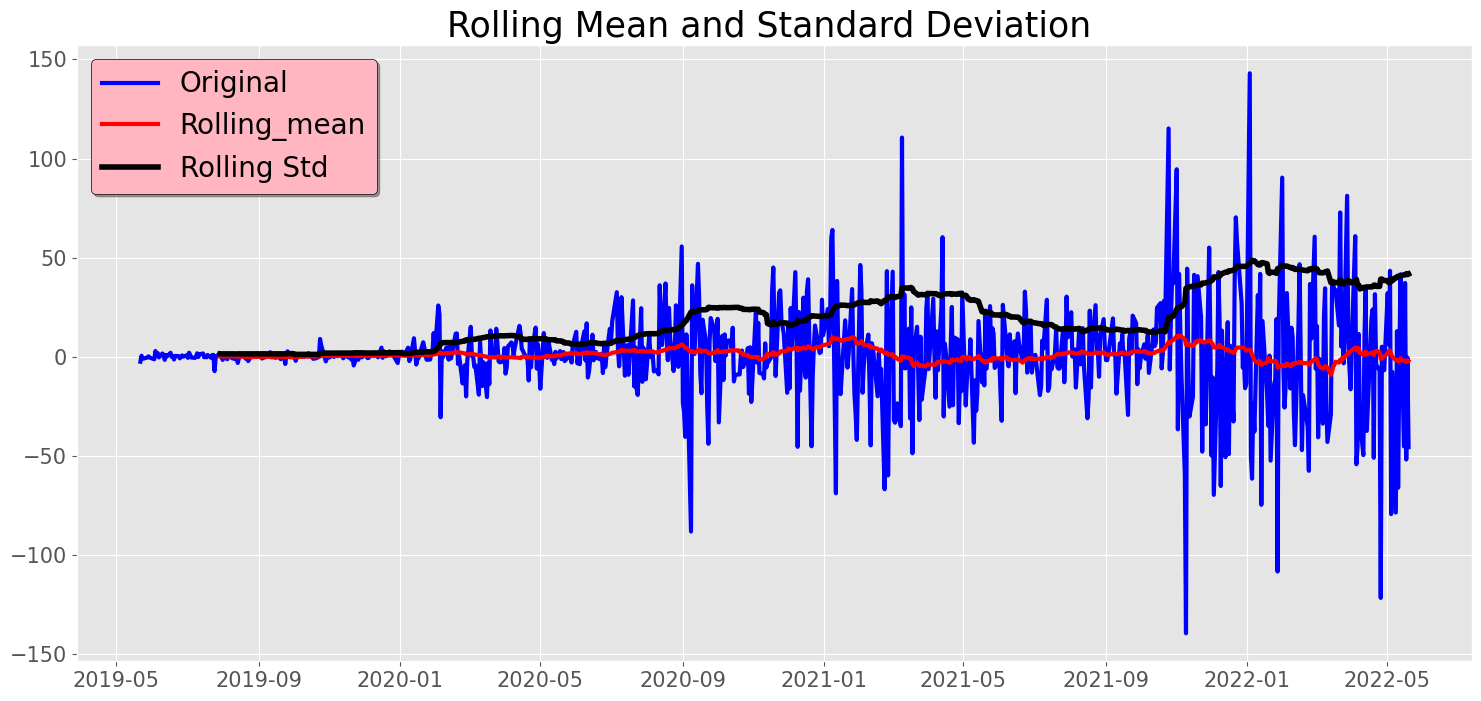

Result of dickey fuller test
Test Stastics                -8.324564e+00
p-value                       3.498786e-13
No. of lags used              8.000000e+00
Number of observation used    7.480000e+02
critical value (%s) %key     -2.568832e+00
dtype: float64


In [43]:
test_stationarity(df_close)

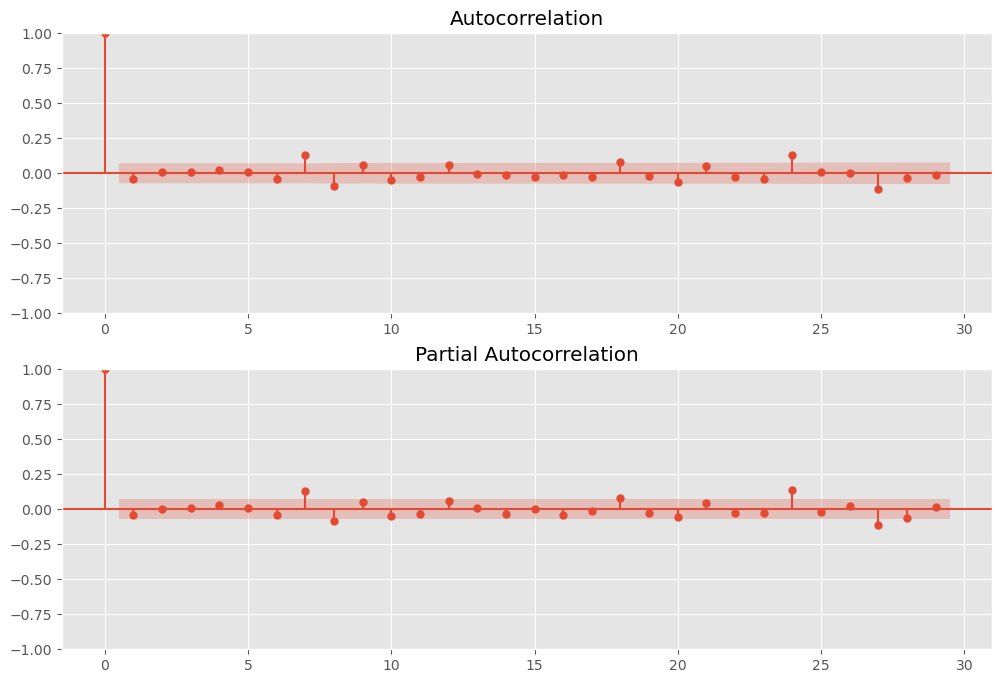

In [44]:
# Now pvalues is less than 0.05, reject the null>> time series is stationary, if not stationary, then again we need to difference

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes=plt.subplots(2,1,figsize=(12,8))
plot_acf(df_close, ax=axes[0])
plot_pacf(df_close, ax=axes[1])
plt.show()

In [45]:
# in time series data, train test split happens on time index
df_close

Date
2019-05-22    -2.469997
2019-05-23     0.551998
2019-05-24    -0.972000
2019-05-28    -0.385998
2019-05-29     0.231998
                ...    
2022-05-16   -45.220032
2022-05-17    37.239990
2022-05-18   -51.799988
2022-05-19    -0.390015
2022-05-20   -45.519958
Name: Close, Length: 757, dtype: float64

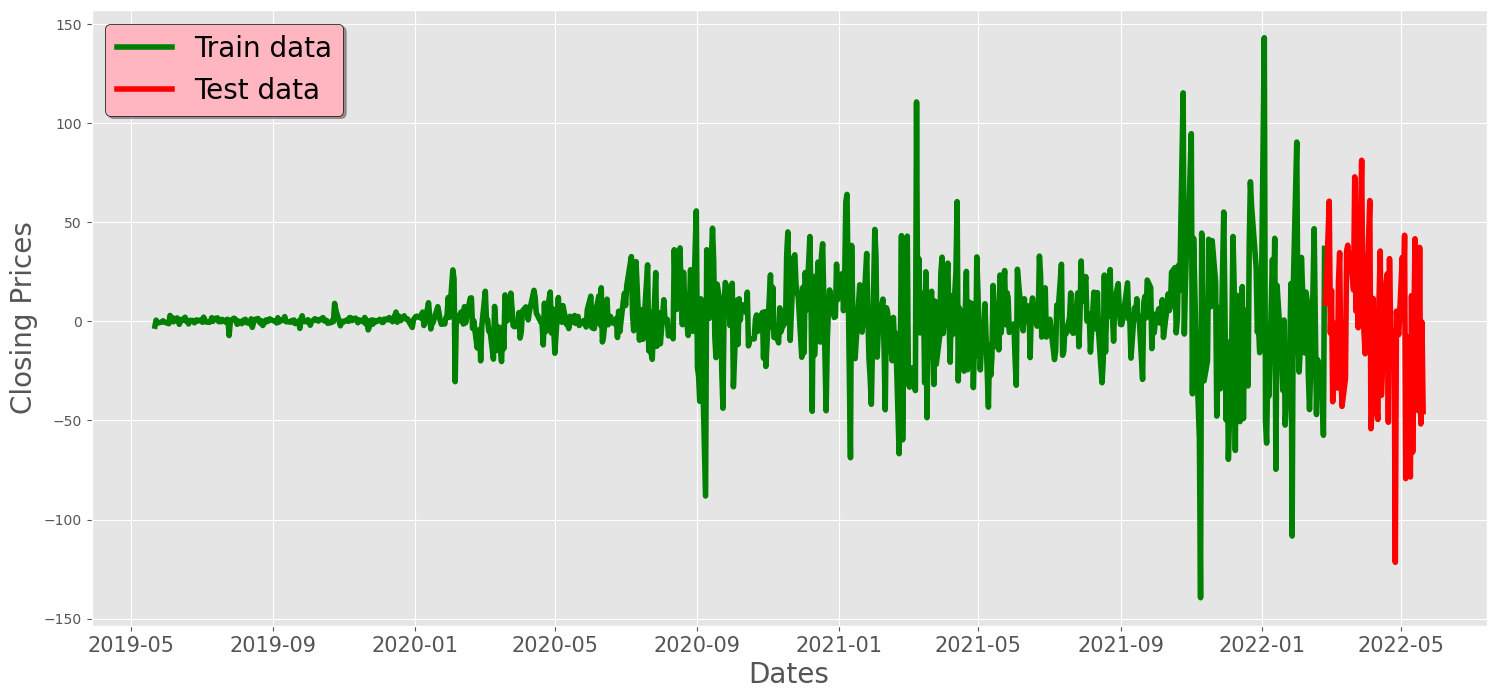

In [46]:
train_data=df_close[0:-60]  # except last 60 
test_data=df_close[-60:]
plt.figure(figsize=(18,8))
plt.grid(True)
plt.xlabel('Dates', fontsize=20)
plt.ylabel('Closing Prices', fontsize=20)
plt.xticks(fontsize=15)
plt.plot(train_data, 'green', label='Train data', linewidth=4)
plt.plot(test_data, 'red', label='Test data', linewidth=4)
plt.legend(fontsize=20, shadow=True, facecolor='lightpink', edgecolor='k')

In [47]:
train_data.shape, test_data.shape

((697,), (60,))

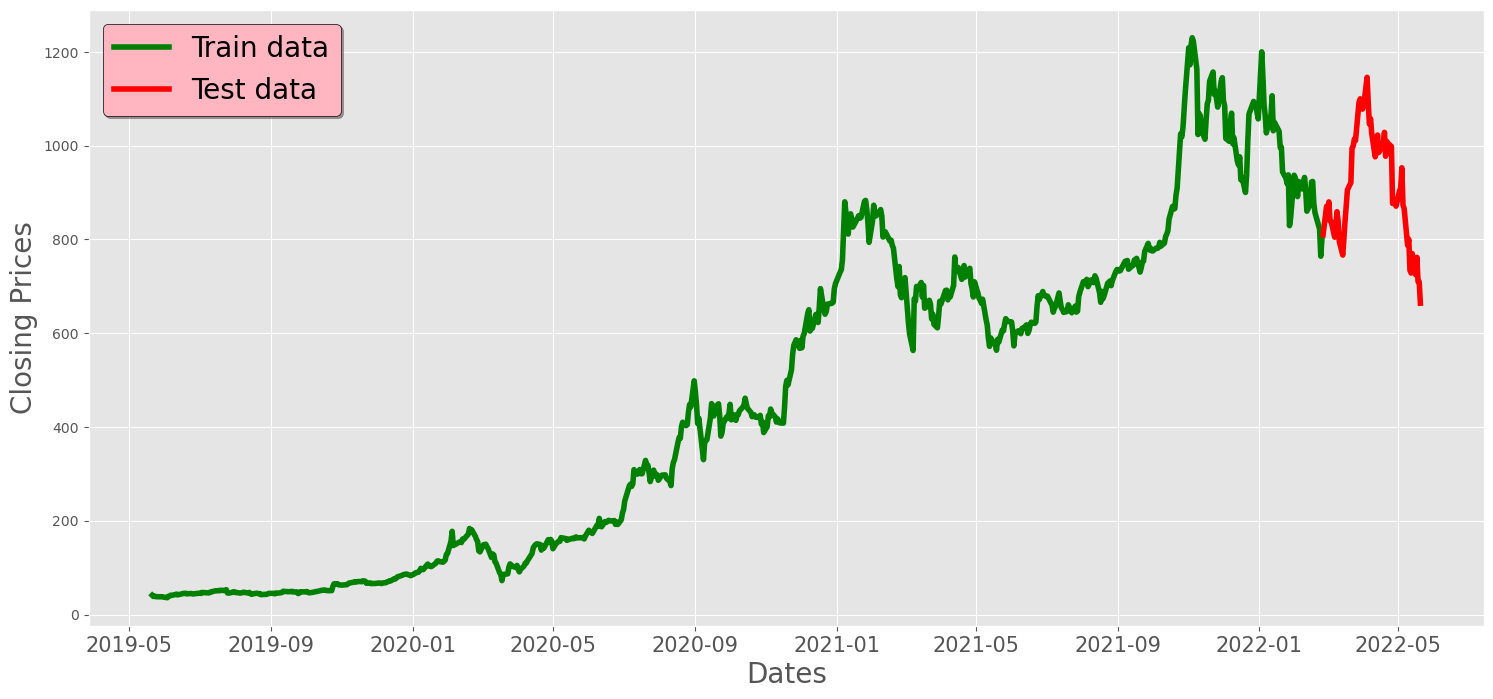

In [48]:
# Now since we will use ARIMA, we donts need stationary time sereis data
# Why ?  - ARIMA itself has inherent differencing parameter, which will make the series
# I >> integrated
# we will use original time series data

train_data=stock_data[0:-60]  
test_data=stock_data[-60:]
plt.figure(figsize=(18,8))
plt.grid(True)
plt.xlabel('Dates', fontsize=20)
plt.ylabel('Closing Prices', fontsize=20)
plt.xticks(fontsize=15)
plt.plot(train_data, 'green', label='Train data', linewidth=4)
plt.plot(test_data, 'red', label='Test data', linewidth=4)
plt.legend(fontsize=20, shadow=True, facecolor='lightpink', edgecolor='k')

In [49]:
# Model Building

In [50]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [51]:
train_data

,Close
Date,
2019-05-21,41.015999
2019-05-22,38.546001
2019-05-23,39.098000
2019-05-24,38.125999
2019-05-28,37.740002
...,...
2022-02-17,876.349976
2022-02-18,856.979980
2022-02-22,821.530029


In [52]:
history=train_data['Close']
history

Date
2019-05-21     41.015999
2019-05-22     38.546001
2019-05-23     39.098000
2019-05-24     38.125999
2019-05-28     37.740002
                 ...    
2022-02-17    876.349976
2022-02-18    856.979980
2022-02-22    821.530029
2022-02-23    764.039978
2022-02-24    800.770020
Name: Close, Length: 698, dtype: float64

In [53]:
model=ARIMA(history, order=(1,1,1))
model

C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [54]:
model=model.fit()

In [55]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                  698
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3150.350
Date:                Thu, 26 Mar 2026   AIC                           6306.700
Time:                        13:52:09   BIC                           6320.340
Sample:                             0   HQIC                          6311.974
                                - 698                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2397      0.699      0.343      0.731      -1.129       1.609
ma.L1         -0.2713      0.690     -0.393      0.694      -1.623       1.080
sigma2       493.6767     11.690     42.231      0.000     470.765     516.588
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              2111.30
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):              31.69   Skew:                             0.09
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.52
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [56]:
model.forecast() # predict is used for a range of values

C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


698    800.204383
dtype: float64

In [57]:
test_data=test_data['Close']
test_data

Date
2022-02-25     809.869995
2022-02-28     870.429993
2022-03-01     864.369995
2022-03-02     879.890015
2022-03-03     839.289978
2022-03-04     838.289978
2022-03-07     804.580017
2022-03-08     824.400024
2022-03-09     858.969971
2022-03-10     838.299988
2022-03-11     795.349976
2022-03-14     766.369995
2022-03-15     801.890015
2022-03-16     840.229980
2022-03-17     871.599976
2022-03-18     905.390015
2022-03-21     921.159973
2022-03-22     993.979980
2022-03-23     999.109985
2022-03-24    1013.919983
2022-03-25    1010.640015
2022-03-28    1091.839966
2022-03-29    1099.569946
2022-03-30    1093.989990
2022-03-31    1077.599976
2022-04-01    1084.589966
2022-04-04    1145.449951
2022-04-05    1091.260010
2022-04-06    1045.760010
2022-04-07    1057.260010
2022-04-08    1025.489990
2022-04-11     975.929993
2022-04-12     986.950012
2022-04-13    1022.369995
2022-04-14     985.000000
2022-04-18    1004.289978
2022-04-19    1028.150024
2022-04-20     977.200012
2022-04

In [58]:
mean_squared_error([test_data[0]], model.forecast())

C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


93.42404966574037

In [59]:
np.sqrt(mean_squared_error([test_data[0]], model.forecast()))

C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


np.float64(9.66561170675402)

In [60]:
# we can treat p, d, q as hyperparameter
p_values=range(0,3)
d_values=range(0,3)
q_values=range(0,3)

for i in p_values:
    for j in d_values:
        for k in q_values:
            print(i,j,k)

0 0 0
0 0 1
0 0 2
0 1 0
0 1 1
0 1 2
0 2 0
0 2 1
0 2 2
1 0 0
1 0 1
1 0 2
1 1 0
1 1 1
1 1 2
1 2 0
1 2 1
1 2 2
2 0 0
2 0 1
2 0 2
2 1 0
2 1 1
2 1 2
2 2 0
2 2 1
2 2 2


In [61]:
def train_arima_model(x, y , arima_order):
    # prepare training dataset
    # make prediction list
    history = [x for x in x]
    predictions = list()
    for t in range(len(y)):
        model = ARIMA(history , order = arima_order)
        model_fit = model.fit()
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)
        history.append(y[t])

    # calculate out of sample error 
    rmse = np.sqrt(mean_squared_error(y,predictions))
    return rmse

def evaluate_models(dataset , test , p_values , d_values, q_values):
    if isinstance(dataset , pd.DataFrame):
        dataset = dataset['Close']
    dataset = dataset.astype('float32')
    best_score , best_cfg = float('inf'), None 
    for p in p_values:
        for d  in d_values:
            for q in q_values:
                order = (p,d,q)
                try:
                    rmse = train_arima_model(dataset, test , order)
                    if rmse < best_score:
                        best_score , best_cfg = rmse , order
                    print('ARIMA%s RMSE = %.3f' %(order , rmse))
                except:
                    continue
    print('Best ARIMA%s RMSE = %.3f' % (best_cfg , best_score))

In [62]:
evaluate_models(train_data, test_data, p_values, d_values, q_values)

ARIMA(0, 0, 0) RMSE = 457.414
ARIMA(0, 0, 1) RMSE = 241.164
ARIMA(0, 0, 2) RMSE = 162.879
ARIMA(0, 1, 0) RMSE = 39.516
ARIMA(0, 1, 1) RMSE = 39.482
ARIMA(0, 1, 2) RMSE = 39.617
ARIMA(0, 2, 0) RMSE = 57.835
ARIMA(0, 2, 1) RMSE = 39.611
ARIMA(0, 2, 2) RMSE = 39.580
ARIMA(1, 0, 0) RMSE = 39.477
ARIMA(1, 0, 1) RMSE = 39.449
ARIMA(1, 0, 2) RMSE = 39.584
ARIMA(1, 1, 0) RMSE = 39.475
ARIMA(1, 1, 1) RMSE = 39.555
ARIMA(1, 1, 2) RMSE = 39.935
ARIMA(1, 2, 0) RMSE = 46.184
ARIMA(1, 2, 1) RMSE = 39.573
ARIMA(1, 2, 2) RMSE = 39.731
ARIMA(2, 0, 0) RMSE = 39.440
ARIMA(2, 0, 1) RMSE = 39.494
ARIMA(2, 0, 2) RMSE = 39.598
ARIMA(2, 1, 0) RMSE = 39.635
ARIMA(2, 1, 1) RMSE = 39.759


C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Lik

ARIMA(2, 1, 2) RMSE = 39.737
ARIMA(2, 2, 0) RMSE = 45.781
ARIMA(2, 2, 1) RMSE = 39.738


C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Lik

ARIMA(2, 2, 2) RMSE = 39.732
Best ARIMA(2, 0, 0) RMSE = 39.440


In [64]:
history = [x for x in train_data['Close']]
predictions = list()
conf_list=list()
for t in range(len(test_data)):
    model = ARIMA(history , order =(2,0,0))
    model_fit = model.fit()
    fc = model_fit.forecast(alpha=0.05)
    predictions.append(fc)
    history.append(test_data[t])
print('RMSE of ARIMA Model: ',np.sqrt(mean_squared_error(test_data, predictions)))

RMSE of ARIMA Model:  39.43995711541688


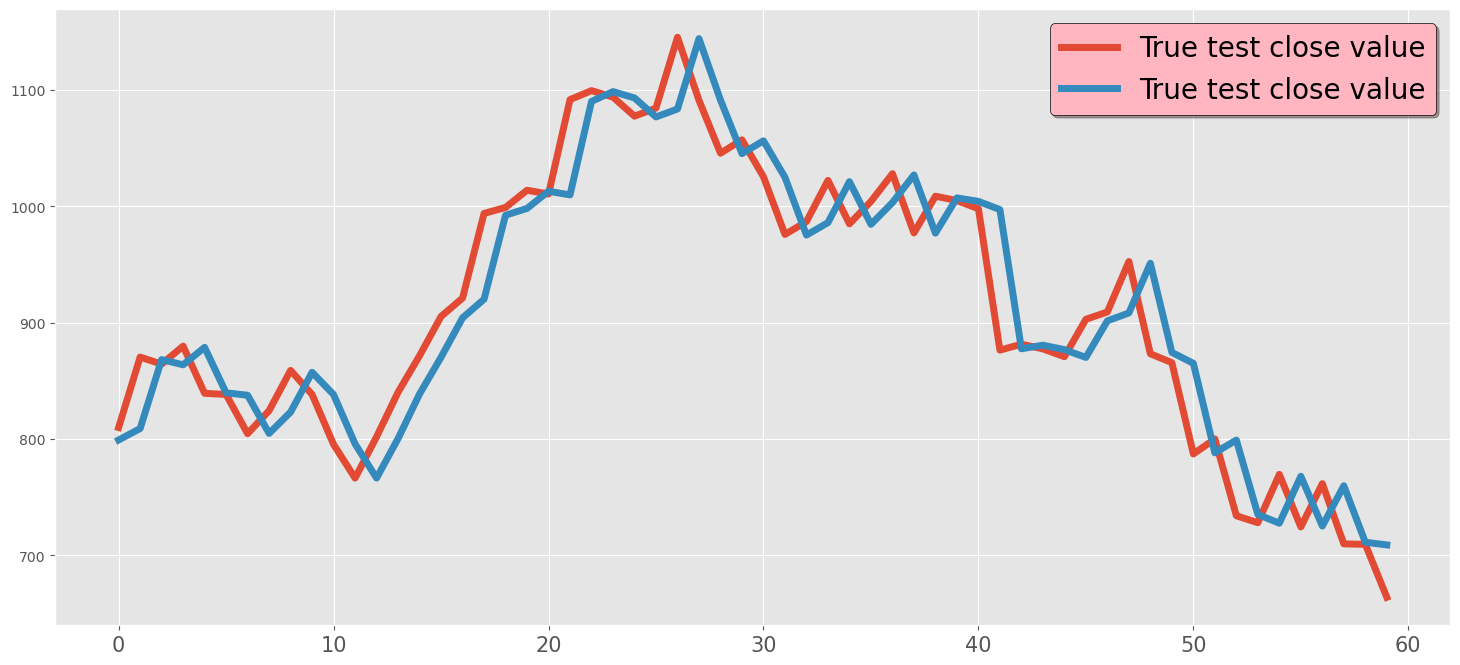

In [65]:
plt.figure(figsize=(18,8))
plt.grid(True)
plt.plot(range(len(test_data)),test_data,label='True test close value',linewidth=5)
plt.plot(range(len(predictions)),predictions,label='True test close value',linewidth=5)
plt.xticks(fontsize=15)
plt.xticks(fontsize=15)
plt.legend(fontsize=20, shadow=True,facecolor='lightpink', edgecolor='k')
plt.show()

In [66]:
fc_series=pd.Series(predictions, index=test_data.index)

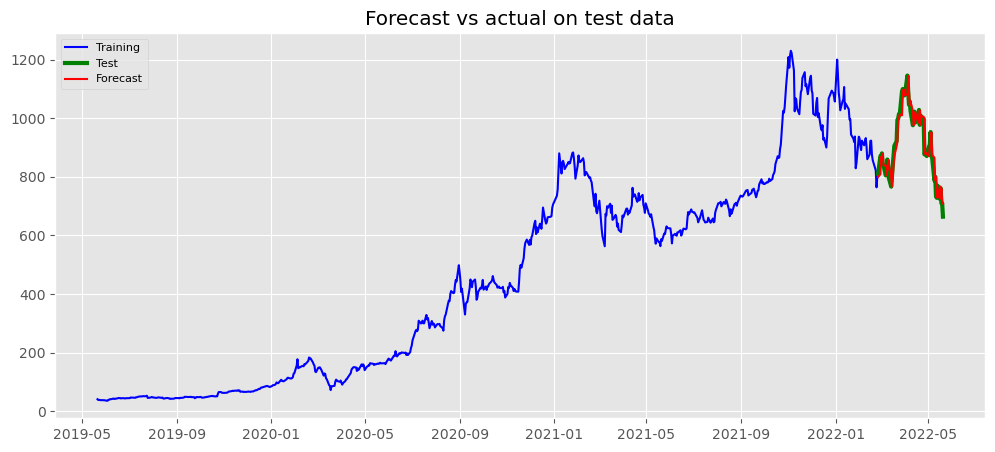

In [68]:
# Forecast value with test data
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data['Close'], label='Training',color='blue')
plt.plot(test_data,label='Test',color='green', linewidth=3)
plt.plot(fc_series, label='Forecast', color='red')
plt.title('Forecast vs actual on test data')
plt.legend(loc='upper left', fontsize=8)
plt.show()

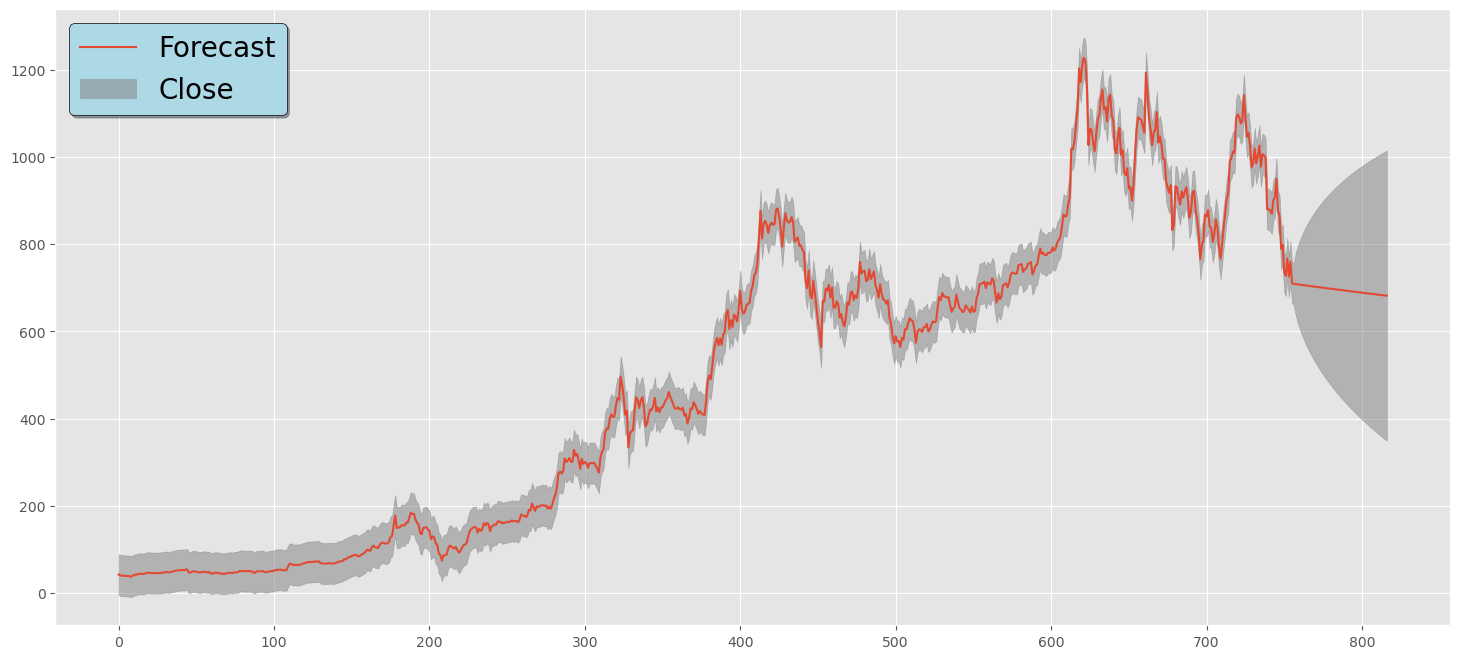

In [69]:
from statsmodels.graphics.tsaplots import plot_predict
fig=plt.figure(figsize=(18,8))
ax1=fig.add_subplot(111)
plot_predict(result=model_fit, start=1, end=len(df_close)+60, ax=ax1)
plt.grid('both')
plt.legend(['Forecast','Close','95% confidence interval'], fontsize=20, shadow=True, facecolor='lightblue', edgecolor='k')
plt.show()

In [70]:
# SARIMA -p,d, q, P, D, s

history = [x for x in train_data['Close']]
predictions = list()
conf_list=list()
for t in range(len(test_data)):
    model = sm.tsa.statespace.SARIMAX(history, order=(0,1,1), seasonal_order=(1,1,1,3))
    model_fit = model.fit()
    fc = model_fit.forecast()
    predictions.append(fc)
    history.append(test_data[t])
print('RMSE of SARIMA Model: ',np.sqrt(mean_squared_error(test_data, predictions)))

RMSE of SARIMA Model:  39.853332510589276


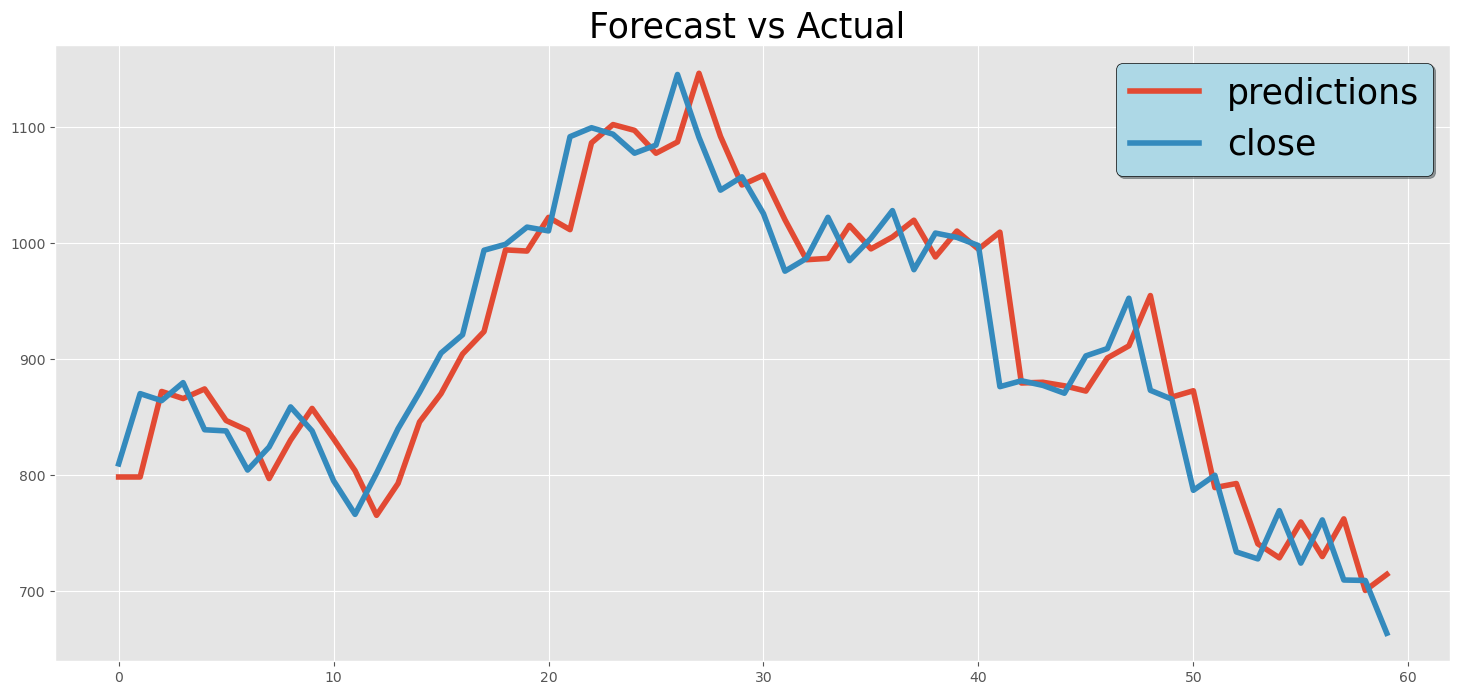

In [73]:
plt.figure(figsize=(18,8))
plt.title('Forecast vs Actual ', fontsize=25)
plt.plot(range(60), predictions,label='predictions', linewidth=4)
plt.plot(range(60), test_data,label='close', linewidth=4)
plt.legend(fontsize=25,shadow=True,facecolor='lightblue', edgecolor='k')